# CartPole — SOLVED & Runnable (Introduction to Gym)

This is the completed version of `CartPole_RandomPolicy_Code.ipynb`.
Your original blank notebook is kept for practice. Run each cell with **Shift+Enter**, top to bottom.

**The problem:** balance a pole on a moving cart. Each step you push the cart
**left (action 0)** or **right (action 1)**. You get **+1 reward per step the pole stays up**.
Episode ends when the pole tilts too far or the cart leaves the screen. Max = 500.


## Exercise 1: Random Policy on CartPole-v1

In [1]:
# Step 1: Import dependencies and create the environment
# NOTE: original notebook used the old "gym". We use the maintained "gymnasium".
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Create the CartPole environment
env = gym.make("CartPole-v1")

print("Action space:", env.action_space)            # Discrete(2) -> 0=left, 1=right
print("Observation space:", env.observation_space)  # [cart pos, cart vel, pole angle, pole ang vel]


Action space: Discrete(2)
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [2]:
# Step 2: Implement a random policy
def random_policy(env):
    # Pick a random valid action (0 or 1). This is the "blank" you had to fill.
    return env.action_space.sample()


In [3]:
# Step 3: Run multiple episodes
num_episodes = 20
rewards = []

for episode in range(num_episodes):
    obs, info = env.reset()      # start a fresh episode
    done = False
    total_reward = 0

    while not done:
        action = random_policy(env)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated   # episode ends if pole fell OR time limit hit
        total_reward += reward

    rewards.append(total_reward)
    print(f"Episode {episode+1}: Total Reward = {total_reward}")


Episode 1: Total Reward = 11.0
Episode 2: Total Reward = 10.0
Episode 3: Total Reward = 66.0
Episode 4: Total Reward = 14.0
Episode 5: Total Reward = 19.0
Episode 6: Total Reward = 17.0
Episode 7: Total Reward = 14.0
Episode 8: Total Reward = 47.0
Episode 9: Total Reward = 25.0
Episode 10: Total Reward = 10.0
Episode 11: Total Reward = 50.0
Episode 12: Total Reward = 34.0
Episode 13: Total Reward = 12.0
Episode 14: Total Reward = 30.0
Episode 15: Total Reward = 13.0
Episode 16: Total Reward = 12.0
Episode 17: Total Reward = 14.0
Episode 18: Total Reward = 17.0
Episode 19: Total Reward = 18.0
Episode 20: Total Reward = 54.0


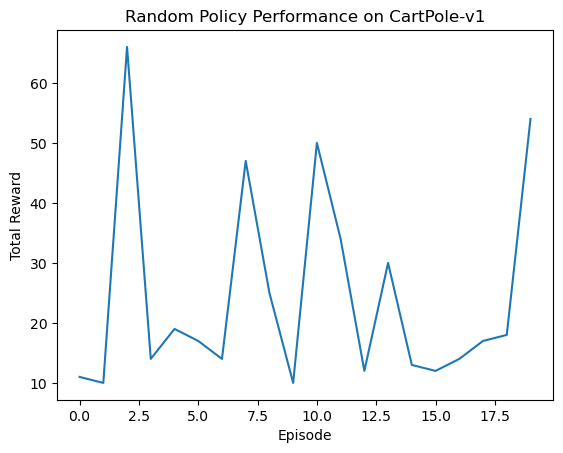

Average reward: 24.35


In [4]:
# Step 4: Analyze performance
plt.plot(rewards)
plt.title("Random Policy Performance on CartPole-v1")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

print("Average reward:", np.mean(rewards))


### Step 5: Discussion (answers)
1. **Why does random fail?** It ignores the pole angle, so it pushes the wrong way half the time. The pole quickly tips past recovery.
2. **What is the reward?** +1 for every timestep the pole stays balanced. Higher total = balanced longer.
3. **How to improve?** Use the observation (especially pole angle) to decide the action -> Exercise 2. Later, *learn* a policy with RL (after you cover Markov Decision Processes).


## Exercise 2: Smarter (rule-based) Policy + Visualization
Now we *use the state*: if the pole leans right, push right; if left, push left. Plus 10% random exploration.

In [5]:
# Step 1: Setup with rendering enabled
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

env = gym.make("CartPole-v1", render_mode="rgb_array")  # rgb_array = give us image frames
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)


Action space: Discrete(2)
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [6]:
# Step 2: A smarter, rule-based policy
def smarter_policy(obs):
    cart_pos, cart_vel, pole_angle, pole_ang_vel = obs
    # 10% of the time act randomly (exploration), so behavior is visible
    if np.random.rand() < 0.1:
        return env.action_space.sample()
    # Otherwise: lean right (angle>0) -> push right(1); else push left(0)
    return 1 if pole_angle > 0 else 0


In [7]:
# Step 3: Run ONE episode and capture frames for the video
frames = []
obs, info = env.reset(seed=0)
total_reward = 0
done = False
while not done:
    frames.append(env.render())          # grab the current image
    action = smarter_policy(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward
env.close()
print(f"Smarter policy survived {len(frames)} steps, total reward = {total_reward}")


Smarter policy survived 42 steps, total reward = 42.0


### Visualization (play it back as a video)

In [8]:
frames_np = [np.array(f).squeeze() for f in frames]   # each frame: (H, W, 3)

fig = plt.figure()
patch = plt.imshow(frames_np[0])
plt.axis("off")

def animate(i):
    patch.set_data(frames_np[i])
    return patch,

anim = animation.FuncAnimation(fig, animate, frames=len(frames_np), interval=30)
plt.close(fig)
HTML(anim.to_jshtml())


## What you just learned
- The Gym loop: `reset()` -> `step(action)` -> read `(obs, reward, terminated, truncated, info)` -> repeat.
- A **random** policy is weak; a policy that **uses the observation** does better.
- Neither *learns* yet. Real RL (learning the best policy automatically) builds on **Markov Decision Processes**, which your course covers next.